# Basics: serine landscape

We will get started by building a very simple fitness landscape for a 3-nucleotide sequence. In this simple fintess landscape, fitness depends on whether the 3-nucleotide sequence codes for Serine, another aminoacid or a Stop codon under the Standard genetic code. Serine is a very the only aminoacid that is encoded by two sets of mutationally disconnected codons (`AGU,AGC` and `UCA,UCC,UCG,UCU`), resulting in a fitness landscape with two isolated fitness peaks.

| Aminoacid | Fitness $\omega$ |
|---------- |:----------------:|
|  Serine   |         2        |
|   Other   |         1        |
|   Stop    |         0        |


In [1]:
# Import required libraries
import numpy as np
import gpmap.plot.mpl as plot

from gpmap.genotypes import get_nodes_df_highlight
from gpmap.datasets import DataSet
from gpmap.space import SequenceSpace
from gpmap.randwalk import WMWalk

An example of this type of landscape is included as a `DataSet` in the package for illustration purposes. The attribute `landscape` contains a `DataFrame` with the fitness `y` associated to each possible sequence

In [2]:
serine = DataSet("serine")
serine.landscape

,y
AAA,1.176405
AAC,1.040016
AAG,1.097874
AAT,1.224089
ACA,1.186756
...,...
TGT,0.963726
TTA,0.932754
TTC,0.964045
TTG,0.918685


## Define a discrete space

The first thing we need to do is to define the discrete space for the evolutionary random walk. We can do this by creating a `SequenceSpace` object. `SequenceSpace` is automatically constructed as a the Cartesian product of site-specific spaces containing the different sets of alleles at each site, an is created by specifying the `seq_lenght` and either `alphabet_type` or `alphabet`, and contains additional methods that are specific to sequence spaces.

In [3]:
serine = DataSet('serine')
space = SequenceSpace(X=serine.landscape.index.values, y=serine.landscape['y'])
print(space)


Sequence Space:
	Type: dna
	Sequence length: 3
	Number of alleles per site: [4, 4, 4]
	Genotypes: [AAA,AAC,AAG,...,TTC,TTG,TTT]
	Function y: [1.18,1.04,1.10,...,0.96,0.92,0.83]


The `DataSet` object provides a method `to_sequence_space` to do this directly

In [4]:
space = serine.to_sequence_space()
print(space)

Sequence Space:
	Type: dna
	Sequence length: 3
	Number of alleles per site: [4, 4, 4]
	Genotypes: [AAA,AAC,AAG,...,TTC,TTG,TTT]
	Function y: [1.18,1.04,1.10,...,0.96,0.92,0.83]


## Define a random walk on the discrete space

Once we have defined our discrete space, we just need to define a random walk on it. 

In [5]:
rw = WMWalk(space)

### Defining the strength of selection

As shown in the Theory section, this random walk is defined by the discrete space but also by an additional hyperparameter `c`. There are 3 different ways in which we define `c` for our random walk:
 
 - Directly through the `Ns` argument. If we are dealing with fitness directly, then $s=1$ and we can set an estimate of the $N_e$ of the species we are modeling. In some cases, we may even deal the scaled fitness e.g. when derived from stationary frequencies, providing a natural choice of $Ns=1$. 
 - By selecting the expected `mean_function` at stationarity. For instance if we are dealing with experimental data derived from a wild-type sequence, we can assume that the wild-type phenotype is a good approximation of the expected phenotypic value at stationarity.
 - By selecting the percentile of expected mean function at stationarity among the values of all genotypes (`mean_function_percentile`) if we do not have a very clear reference of what could be a functional phenotype.
 
In this case, lets try with a mean function at stationarity of 1.5, which implies that a substantial probability would lie on the few genotypes with fitness 2 corresponding to the codons encoding Serine, and check what ``Ns`` was required to reach that stationary function.

In [6]:
rw.set_Ns(mean_function=1.5)
print('Mean function at stationarity of 1.5 was reached at Ns={:.2f}'.format(rw.Ns))

Mean function at stationarity of 1.5 was reached at Ns=2.13


Internally, the method `set_Ns` computes the stationary frequencies, this is, the fraction of time that the random walk spends in each possible genotype. 
By calculating the stationary frequencies under this evolutionary model, we can see that the frequencies at which we expect to find different genotypes under this evolutionary model span 2 orders of magnitude.

In [7]:
freqs = rw.calc_stationary_frequencies(Ns=rw.Ns)
print('Stationary frequencies range from {:.5f} to {:.5f}'.format(freqs.min(), freqs.max()))

Stationary frequencies range from 0.00077 to 0.10425


From those frequencies, it is easy to compute the expected fitness under that distribution and verify that it matches the desired one

In [8]:
np.round(rw.calc_stationary_mean_function(freqs), 2)

1.5

### Calculating the coordinates of the visualization

Once the random walk is defined, we can numerically calculate the coordinates of our low dimensional representation. 
We can specify the number of components to compute with `n_components`.


In [9]:
rw.calc_visualization(Ns=rw.Ns, n_components=20)

The coordinates of the embedding are stored in the attribute `nodes_df` of the `WMWalk` object as a standard pandas `DataFrame` object that we can use for plotting

In [10]:
rw.nodes_df.head()

,1,2,3,4,5,6,7,8,9,10,...,13,14,15,16,17,18,19,20,function,stationary_freq
AAA,0.407809,0.868655,0.077718,-0.881550,0.062912,1.472110,-0.606877,-0.747799,0.084493,0.925630,...,0.189047,0.204727,0.305264,-1.344604,-0.426318,-1.001960,-0.108886,0.201358,1.176405,0.013284
AAC,0.629546,0.280194,-0.609875,0.203409,0.112413,0.803236,-0.580154,-0.518404,0.318867,0.156468,...,0.264463,0.597901,-0.411744,-0.029703,0.110071,-0.028554,-0.282016,-0.546921,1.040016,0.009940
AAG,0.391836,0.755212,0.062261,-0.091491,1.218855,1.151346,-0.585330,-0.711375,0.023780,-0.164794,...,0.115422,-0.085225,-1.077083,-0.223406,-0.330539,0.199638,0.459709,-1.482576,1.097874,0.011241
AAT,0.692524,0.172758,0.678345,0.175420,0.145846,0.818042,-0.591270,-0.594482,0.109683,0.096941,...,0.798394,0.046978,-0.349036,0.390893,-0.378651,-0.712831,0.331475,-0.495848,1.224089,0.014702
ACA,-0.249561,0.195755,-0.026722,-0.982568,-0.188220,0.845132,0.357073,-0.301584,0.056766,0.018231,...,0.620715,0.319452,0.686605,0.043641,0.009723,0.227721,-0.524040,0.930972,1.186756,0.013580


Ideally, we also want the representation to show how different sequences or genotype are mutationally connected to each other. We can obtain this information in a `DataFrame` using the `SequenceSpace.get_edges_df` method

In [11]:
edges_df = rw.space.get_edges_df()
edges_df.head()

,i,j
0,0,1
1,0,2
2,0,3
3,1,0
4,1,2


## How to plot a landscape visualization

As the output of the visualization is a simple `DataFrame` with the coordinates, it allows plotting with any library or other programming language. However, we also provide some functions to facilitate the user this job using different libraries for different funcitonalities.

> **Note** The indices of the adjacent genotypes must match the ordering in `nodes_df` for plotting. While our `SequenceSpace` ensure this is true, if you are generating the `nodes_df` and `edges_df` independently, make sure that is the case when using our plotting functionality

The main functions are built using [matplotlib](https://matplotlib.org/) and can be easily used for some basic plots


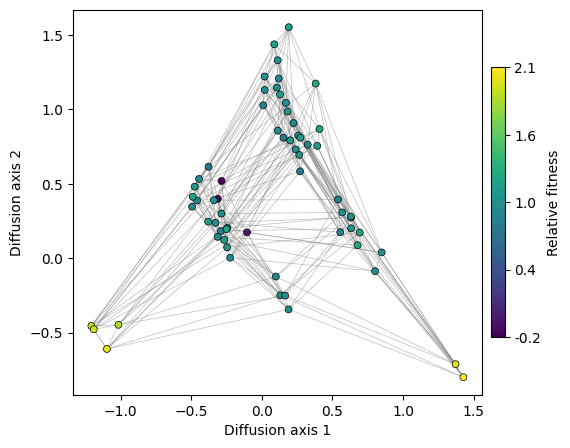

In [12]:
fig, axes = plot.init_fig(1, 1, colsize=6, rowsize=5)
plot.plot_visualization(axes, rw.nodes_df, edges_df=edges_df, x='1', y='2',
                        nodes_lw=0.5,
                        nodes_color='function', nodes_cmap_label='Relative fitness',
                        nodes_size=25, edges_alpha=0.5)

Now that we have a nice visualization of the structure of the landscape, we can easily see the main qualitative properties of this simple landscape: it consists of two main fitness peaks that are separated appart from each other along Diffusion axis 1. Diffusion axis 2 separates genotypes with high fitness from those with low fitness that are at an increasing number of mutations away from any of the two fitness peaks. 

We can look at other Diffusion axis as easily as shown below

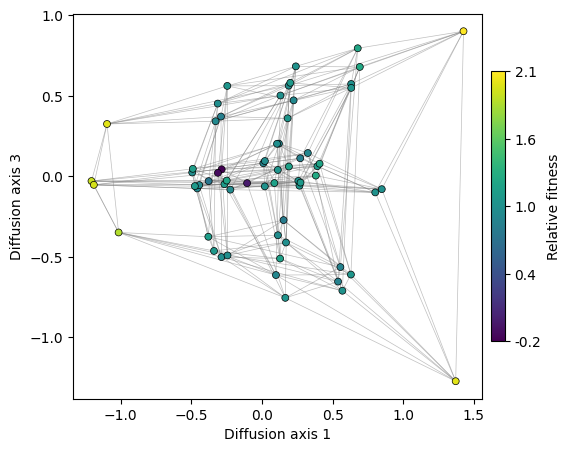

In [13]:
fig, axes = plot.init_fig(1, 1, colsize=6, rowsize=5)
plot.plot_visualization(axes, rw.nodes_df, edges_df=edges_df, x='1', y='3',
                        nodes_lw=0.5,
                        nodes_color='function', nodes_cmap_label='Relative fitness',
                        nodes_size=25, edges_alpha=0.5)

Thus, we can see that Diffusion axis 3 shows the variability within each of the fitness peaks. The two genotypes in the AGY peak are more separated than those at the UCN fitness peak containing 4 sequences. This is because we can only move through the small peak by the single mutation that connects the two genotypes, while the remaining mutations are deleterious. In contrast, any mutation in the last base of the genotypes at the big peak is neutral, as they keep coding for Serine. Thus, as there are many more ways to evolve from one to another, the required time for that to happen is also shorter.

## How many dimensions to plot?

A natural question in any dimensionality reduction method, such as this or Principal Component Analysis (PCA), is: how many dimensions do we need to retain the most relevant information in the data? In other words, how can we reasonably choose the number of dimensions to represent our data?

In this section we will discuss a few non-exclusive approaches to determine the number of relevant dimensions or Diffusion axes to represent and the rationale behind them

### Explore relaxation times associated to the diffusion axes

In PCA, the eigenvalues of the covariance matrix are related to the variance explained by each component of the low dimensional representation. We can use the relative contributions of the different components to choose the number of axes that retain a reasonably high % of total variance. In our case, the eigenvalues $\lambda_k$ for the rate matrix $\mathbf{Q}$ represent the decay rates associated to the different components. We are interested in the components that decay particularly slowly, as they represent the strongest barriers to diffusion induced by structure of the fitness landscape. Thus, instead of looking at the variance explained by each component, we can represent the average relaxation time $\left(\frac{1}{-\lambda_k}\right)$ associated to each component for increasingly large $k$'s.

> **Note** that the relaxation times have units of expected number of substitutions.


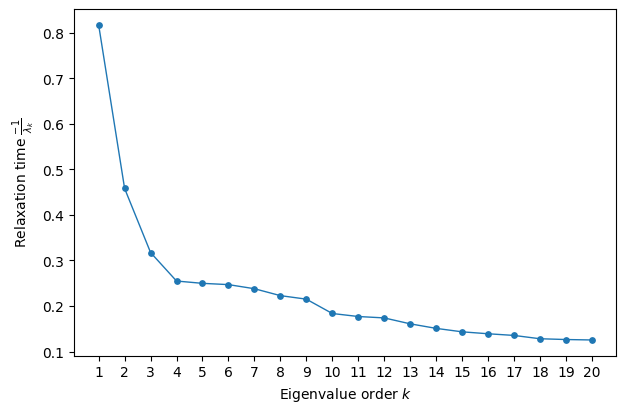

In [14]:
fig, axes = plot.init_fig(1, 1, colsize=7, rowsize=4.5)
plot.plot_relaxation_times(rw.decay_rates_df, axes=axes)

Here, we observe that the first three Diffusion axes, especially the first, stand out compared to the others, which exhibit much more similar behavior. In other words, the decay rates associated with components \( k > 4 \) operate on the same fast scale and are therefore unlikely to represent modes with long-lasting effects on the approach to stationarity.


### Look for a large eigengap

An alternative approach for selecting the relevant number of dimensions is to look for an eigengap—that is, a sudden change in the eigenvalues (or relaxation times in this case) compared to the variability between consecutive eigenvalues before and after the gap.

In this case, the largest gap occurs between dimensions 1 and 2. Although dimensions 2 and 3 capture some relevant details about the geometry of the landscape, dimension 1 alone is sufficient to separate the two main fitness peaks of our landscape.

### Compare with the relaxation time under neutral evolution

In our case, we can not only compare the time scales associated with different components, but we also have an absolute reference time scale for comparison: that of the neutral process. Thus, we are primarily interested in components that decay more slowly than the slowest component of the neutral evolutionary dynamics. If there are no mutational biases, the neutral relaxation rate is equal to the reciprocal of the number of alleles per site ($\alpha = 4$ in our case).

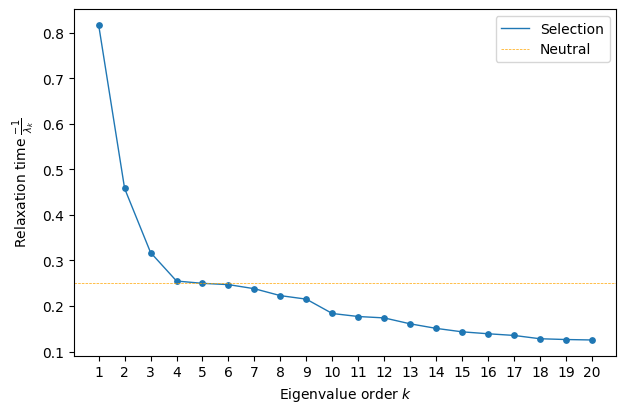

In [15]:
fig, axes = plot.init_fig(1, 1, colsize=7, rowsize=4.5)
plot.plot_relaxation_times(rw.decay_rates_df, axes=axes, neutral_time=1/4.)

Now, we see that only the first three components decay significantly more slowly than neutral evolution, suggesting that the main features of the serine landscape are well captured by a three-dimensional representation.  

## Exploring Different Selection Strengths  

So far, we have treated the strength of selection, `Ns`, as a hyperparameter that must be set a priori. However, rather than aiming to generate a single, definitive visualization, it can be useful to consider a **one-dimensional family of visualizations** that span the full range of selection strengths—from neutral evolution to a regime of very strong selection, where the population remains almost exclusively in the fittest genotype.  

To achieve this, we must recalculate the embedding for each selection strength, making this a more computationally expensive plot. The function `figure_Ns_grid` requires a `RandomWalk` object, allowing it to iterate over either a reasonable default range or a user-provided range of population sizes.  



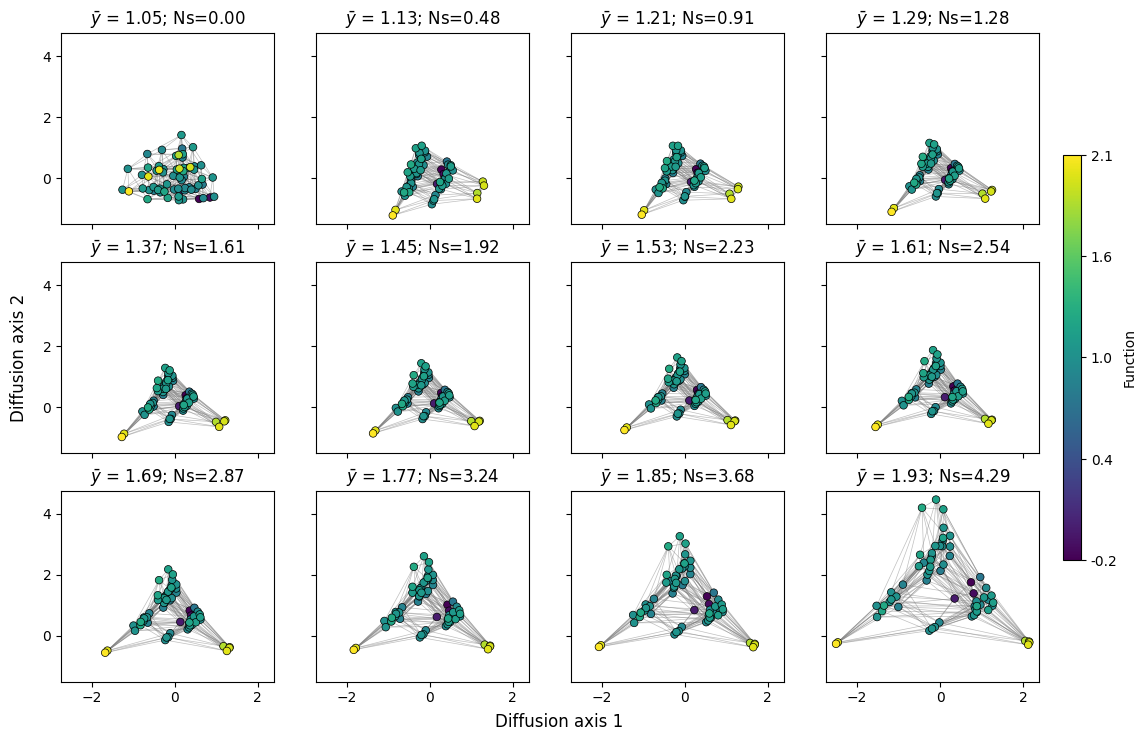

In [16]:
plot.figure_Ns_grid(rw, nodes_color='function', pmin=0, pmax=0.8,
                    nodes_size=30, edges_alpha=0.5, nodes_lw=0.5)


Here, we can clearly observe the effect of selection strength or population size on the dynamics of the evolutionary process. Under neutral evolution, reaching a genotype from another only depends on the number of mutations separating them and every path has the same probability, making every sequence very accessible to each other. As selection strength increases, deleterious mutations are less likely to fix in the population, making it more difficult to cross fitness valleys, pulling apart highly inaccessible sets of genotypes and highlighting finer details of the fitness landscape geometry.  

Similarly, we can observe how the relaxation times of different components change with population size.


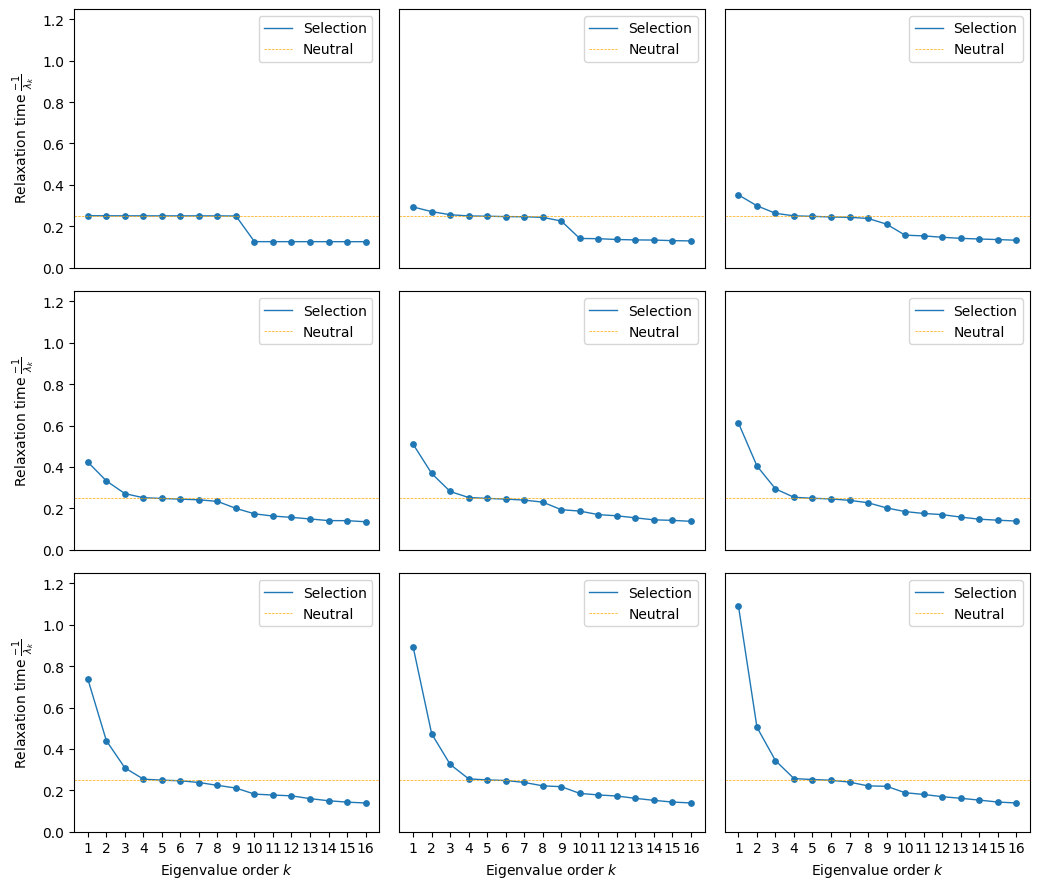

In [17]:
mean_functions = np.linspace(1.05, 1.6, 9)

fig, subplots = plot.init_fig(3, 3, colsize=3.5, rowsize=3)
subplots = subplots.flatten()

for i, (axes, mean_function) in enumerate(zip(subplots, mean_functions)):
    rw.calc_visualization(mean_function=mean_function, n_components=16)
    plot.plot_relaxation_times(rw.decay_rates_df, axes=axes,
                               neutral_time=1/4.)
    
    axes.set_ylim((0, 1.25))
    if i not in [0, 3, 6]:
        axes.set(ylabel='', yticks=[])
    if i < 6:
        axes.set(xlabel='', xticks=[])
    
fig.tight_layout()

We can see that at low population sizes the first 9 components have virtually the same contribution, which is inherent to a uniform random walk on sequence space with 4 alleles and 3 sites. As selection starts to act, we can see how the relaxation time associated to the first component increases, since crossing the valley between the two peaks becomes harder and harder. 

## How to characterize peaks

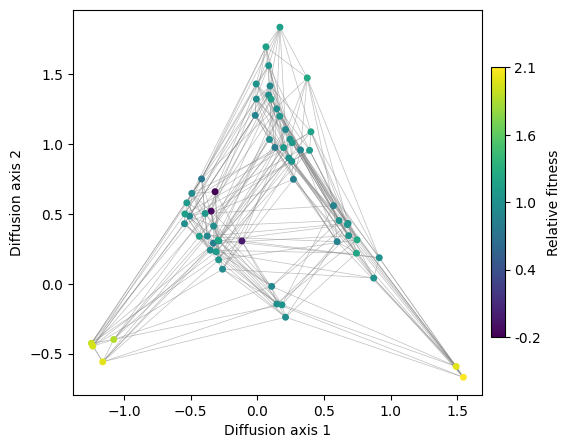

In [18]:
fig, axes = plot.init_fig(1, 1, colsize=6, rowsize=5)
plot.plot_visualization(axes, rw.nodes_df, edges_df=edges_df, x='1', y='2',
                        nodes_color='function', nodes_cmap_label='Relative fitness',
                        nodes_size=25, edges_alpha=0.5)

Now, we have a clear visualization of the landscape structure, where two main fitness peaks are separated along Diffusion axis 1. Meanwhile, Diffusion axis 2 distinguishes high-fitness genotypes from low-fitness ones, which are progressively further away in terms of mutations.  

A natural question arises: **What are the sequences at the different fitness peaks?** One simple approach is to systematically color genotypes based on their sequence or subsequence. This is particularly useful when we have a reasonable hypothesis about the nature of the fitness peaks.  

In this case, we have a strong prior: the two isolated sets of codons that encode **Serine**. We can directly highlight these sets of sequences to examine their placement in the embedding. To facilitate this, we provide the utility function `get_nodes_df_highlight`, which extracts a subset of genotypes from the `nodes_df` dataframe and adds an additional column annotating the assigned genotype sets, using **IUPAC motifs** in this case.

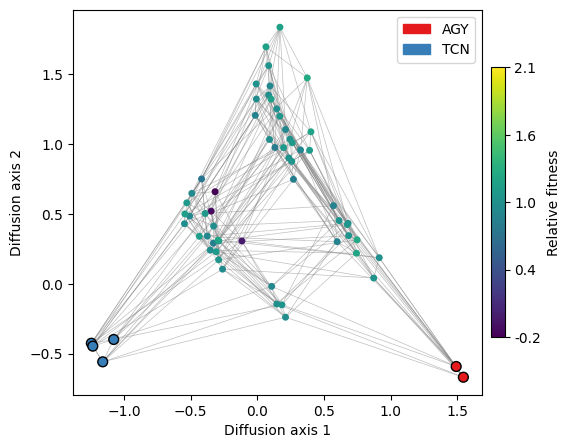

In [19]:
df = get_nodes_df_highlight(rw.nodes_df, genotype_groups=['TCN', 'AGY'])
plot.plot_nodes(axes, df, color='group', x='1', y='2', size=50, palette='Set1', lw=1)
fig

We can indeed see that the peaks correspond to the distinct sets of codons that encode the Serine amino acid. However, in a real scenario, we would rarely know in advance which sequences make up the different fitness peaks.  

A useful strategy is to generate a series of plots where genotypes are sequentially colored based on the alleles at each position. This approach allows us to track how specific genotypes or groups of genotypes light up for different alleles at each position. By examining these patterns, we can effectively identify the sequence features that characterize different regions of the visualization.


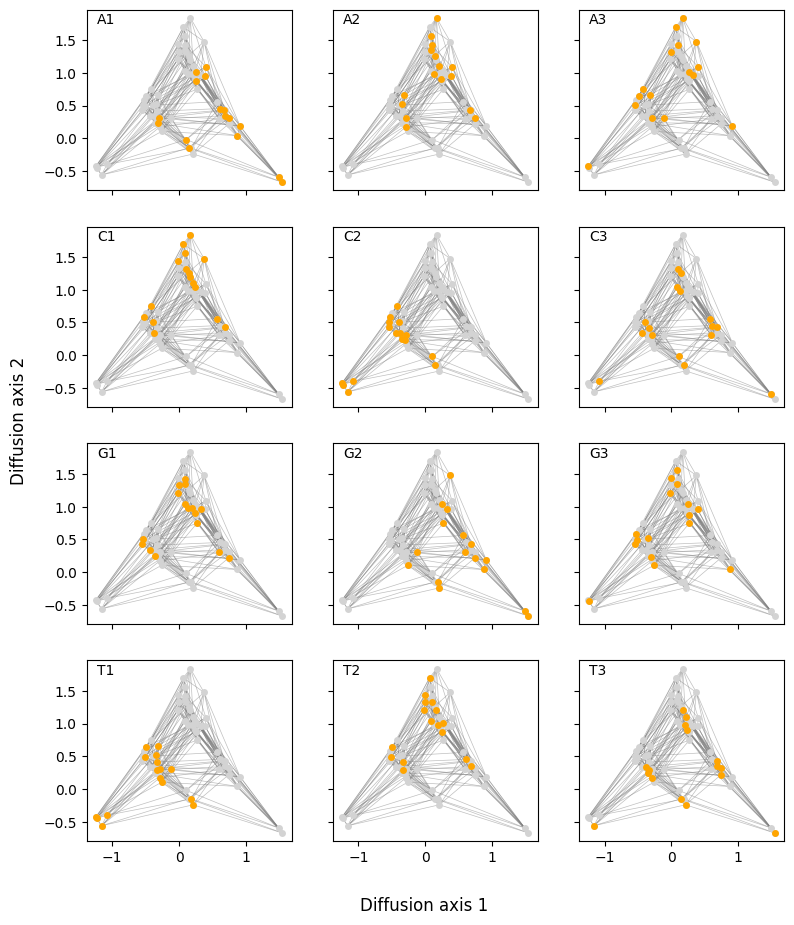

In [20]:
plot.figure_allele_grid(rw.nodes_df, edges_df=edges_df, x='1', y='2',
                        nodes_size=25, edges_alpha=0.5)

This is an example of how useful is to create different versions of the visualization coloring the genotypes by different sequence-features. This strategy can be to see the distribution of any other sequence feature e.g. the effect of specific mutations across all possible genetic backgrounds. For instance, lets now color sequences according to the effect of an A3G substitution. 


In [21]:
s1 = ["{}A".format(x[:2]) for x in rw.nodes_df.index]
s2 = ["{}T".format(x[:2]) for x in rw.nodes_df.index]
rw.nodes_df["A3T"] = (
    rw.nodes_df.loc[s2, "function"].values - rw.nodes_df.loc[s1, "function"].values
)
rw.nodes_df.head()


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,function,stationary_freq,group,A3T
AAA,0.402398,1.089364,0.064931,-0.618206,0.296589,1.733786,-0.685781,-0.314762,-0.818411,-1.098608,-0.134203,-0.167206,0.279827,0.169596,0.478515,-1.375657,1.176405,0.011499,NaN,0.047684
AAC,0.675807,0.424534,-0.601969,0.324595,0.210814,0.745217,-0.486268,-0.580976,-0.468920,-0.167147,-0.151332,0.180912,0.274820,0.726750,-0.318883,-0.080476,1.040016,0.008164,NaN,0.047684
AAG,0.392195,0.956625,0.053097,0.196044,1.339569,1.134183,-0.813210,-0.214003,-0.755367,0.271488,0.951082,0.390761,0.143220,0.062959,-1.229451,-0.357045,1.097874,0.009441,NaN,0.047684
AAT,0.748582,0.315379,0.637856,0.348715,0.220449,0.832080,-0.588693,-0.272760,-0.511694,-0.111372,-0.377394,0.455119,0.836041,0.122532,-0.387732,0.436716,1.224089,0.012963,NaN,0.047684
ACA,-0.294422,0.312591,-0.022744,-0.792949,0.021352,1.084650,0.404155,0.050491,-0.349789,-0.226636,0.421384,-0.709085,0.824103,0.148693,0.701512,0.187700,1.186756,0.011802,NaN,-0.201892


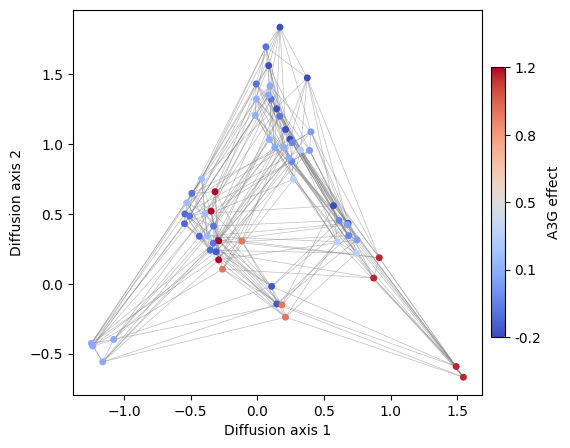

In [22]:


fig, axes = plot.init_fig(1, 1, colsize=6, rowsize=5)
plot.plot_visualization(
    axes,
    rw.nodes_df,
    edges_df=edges_df,
    x="1",
    y="2",
    nodes_color="A3T",
    nodes_cmap='coolwarm',
    nodes_cmap_label="A3G effect",
    nodes_size=25,
    edges_alpha=0.5,
)


## Advanced plots

In this section, we will expand on the possibilities of the plotting functions implemented

- More customized plots using [matplotlib](https://matplotlib.org/)
- Interactive plots in standard html format using [plotly](https://plotly.com/python/)
- Efficient plotting of particularly large landscapes (over 1M genotypes), when rendering by standard libraries becomes too costly, using [datashader](https://datashader.org/)

### Customize plots in matplotlib

We have previously generated simple plots using a high level function that took care of plotting everything. However, the plotting is internally divided into two basic and flexible functions, which allow us to build more complex plots.

- nodes plotting
- edges plotting

For plotting the nodes, we just need to provide the dataframe `nodes_df` with the embedding and specify which dimensions we want to show and what we want to color by, as well as other classical parameters as size or edge color and width, as in a regular scatterplot.

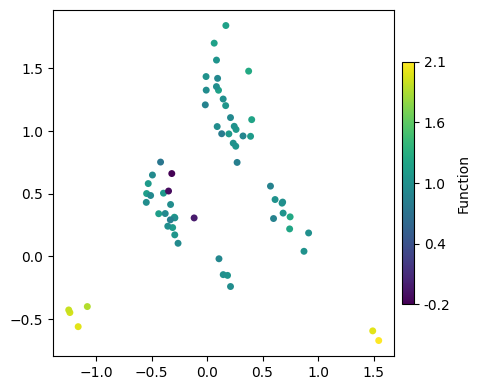

In [23]:
fig, axes = plot.init_fig(1, 1, colsize=5, rowsize=4.5)
plot.plot_nodes(axes, rw.nodes_df, x='1', y='2', color='function', size=25)

We can either color by a column in the `DataFrame` or specify a fixed color. The same goes for the node size

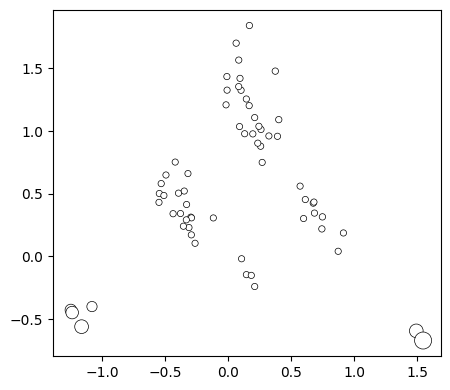

In [24]:
fig, axes = plot.init_fig(1, 1, colsize=5, rowsize=4.5)
plot.plot_nodes(axes, rw.nodes_df, x='1', y='2', color='white', size='stationary_freq',
                edgecolor='black', lw=0.5, min_size=20, max_size=150)

Now we can easily add the edges to show how genotypes are connected to each other by single point mutations

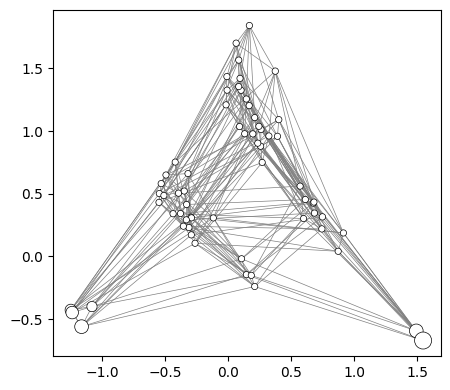

In [25]:
plot.plot_edges(axes, rw.nodes_df, edges_df=edges_df, alpha=1)
fig

### 3D visualization

As we have recalculated the diffusion axes for plotting the decay of relaxation times, our `RandomWalk` object now contains the embedding calculated under the strongest selective regime, which will allow us to see finer details of the fitness peaks when looking at more diffusion axis. 

We can generate a 3D plot by just specifying which axis is shown in the `z` argument, by default set to `None` to do 2D representations. 

In [26]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

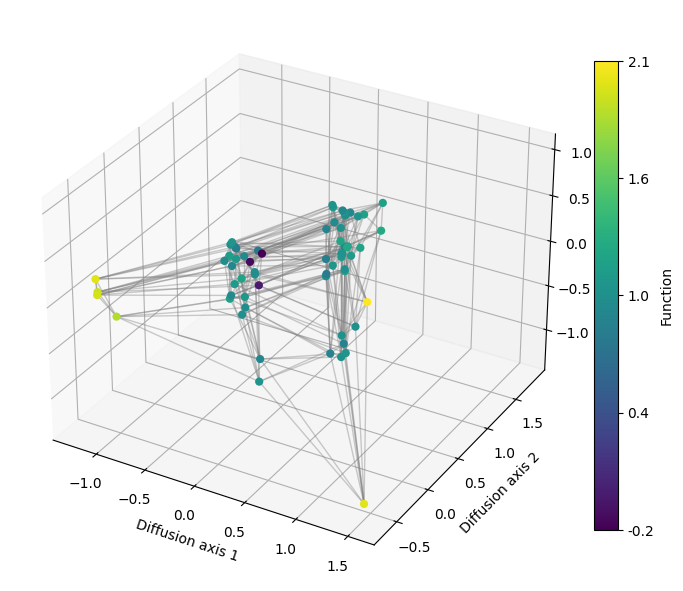

In [27]:
fig = plt.figure(figsize=(7, 7))
axes = fig.add_subplot(111, projection='3d')
plot.plot_visualization(axes, rw.nodes_df, edges_df=edges_df,
                        x='1', y='2', z='3', nodes_color='function',
                        nodes_size=35, edges_width=1, edges_alpha=0.4)

fig.tight_layout()

### Interactive visualization

We can use [plotly](https://plotly.com/python/) to generate interactive visualizations where we can zoom in and out, show the genotypes on the nodes when hovering over them with the mouse, and rotating to have different views when having a 3D plot

In [28]:
import gpmap.plot.ply as plot

In [29]:
fig = plot.plot_visualization(rw.nodes_df, edges_df=edges_df,
                              nodes_color='function', nodes_size=10, edges_width=1)
fig.show('notebook')

In [30]:
fig = plot.plot_visualization(rw.nodes_df, edges_df=edges_df, z='3',
                             nodes_color='function', nodes_size=4, edges_width=1)
fig.show('notebook')